<a href="https://colab.research.google.com/github/oluwafemighty/Codveda-Data-Analysis-Internship/blob/main/Oluwafemi_Ezekiel_Codveda_Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/Codveda_Intership/4) house Prediction Data Set.csv'
df = pd.read_csv(path)

In [ ]:
df_cleaned = df.fillna(df.mean(numeric_only=True))

df_cleaned = df_cleaned.fillna("Unknown")

df_cleaned = df_cleaned.drop_duplicates()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print("Data Cleaning and Preprocessing Task Complete!")

Original shape: (505, 1)
Cleaned shape: (505, 1)
Data Cleaning and Preprocessing Task Complete!


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/Codveda_Intership/4) house Prediction Data Set.csv'

try:
    df_fixed = pd.read_csv(path, delim_whitespace=True)
except:
    df_fixed = pd.read_csv(path, sep='\s+')

print(f"New Shape: {df_fixed.shape}")
df_cleaned = df_fixed.drop_duplicates()

New Shape: (505, 14)


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9575/2595729371.py:10: SyntaxWarning: invalid escape sequence '\s'
  df_fixed = pd.read_csv(path, sep='\s+')
/tmp/ipykernel_9575/2595729371.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_fixed = pd.read_csv(path, delim_whitespace=True)


In [ ]:
print("--- SUMMARY STATISTICS ---")
print(df_cleaned.describe())

print("\n--- DATA MODE ---")
print(df_cleaned.mode().iloc[0])

--- SUMMARY STATISTICS ---
          0.00632       18.00       2.310           0      0.5380      6.5750  \
count  505.000000  505.000000  505.000000  505.000000  505.000000  505.000000   
mean     3.620667   11.350495   11.154257    0.069307    0.554728    6.284059   
std      8.608572   23.343704    6.855868    0.254227    0.115990    0.703195   
min      0.009060    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082210    0.000000    5.190000    0.000000    0.449000    5.885000   
50%      0.259150    0.000000    9.690000    0.000000    0.538000    6.208000   
75%      3.678220   12.500000   18.100000    0.000000    0.624000    6.625000   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

            65.20      4.0900           1       296.0       15.30      396.90  \
count  505.000000  505.000000  505.000000  505.000000  505.000000  505.000000   
mean    68.581584    3.794459    9.566337  408.459406   18.461782  356.594376   


In [ ]:
print("--- CORRELATION MATRIX ---")
correlation_matrix = df_cleaned.corr()
print(correlation_matrix)

--- CORRELATION MATRIX ---
          0.00632     18.00     2.310         0    0.5380    6.5750     65.20  \
0.00632  1.000000 -0.200283  0.406251 -0.056132  0.420934 -0.218978  0.352701   
18.00   -0.200283  1.000000 -0.534022 -0.042550 -0.516574  0.311835 -0.569524   
2.310    0.406251 -0.534022  1.000000  0.062350  0.764556 -0.391330  0.645543   
0       -0.056132 -0.042550  0.062350  1.000000  0.091134  0.091497  0.086461   
0.5380   0.420934 -0.516574  0.764556  0.091134  1.000000 -0.302127  0.731461   
6.5750  -0.218978  0.311835 -0.391330  0.091497 -0.302127  1.000000 -0.240211   
65.20    0.352701 -0.569524  0.645543  0.086461  0.731461 -0.240211  1.000000   
4.0900  -0.379627  0.664395 -0.708848 -0.099109 -0.769221  0.205170 -0.747872   
1        0.625396 -0.311717  0.594167 -0.007907  0.611758 -0.209277  0.456232   
296.0    0.582568 -0.314351  0.720561 -0.035965  0.668141 -0.291680  0.506527   
15.30    0.289394 -0.391713  0.380955 -0.122570  0.188918 -0.355116  0.261724   
3

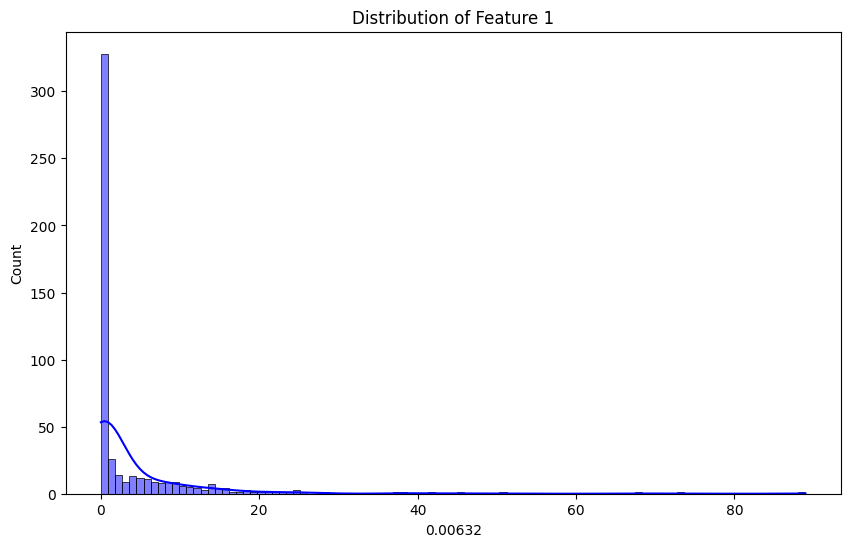

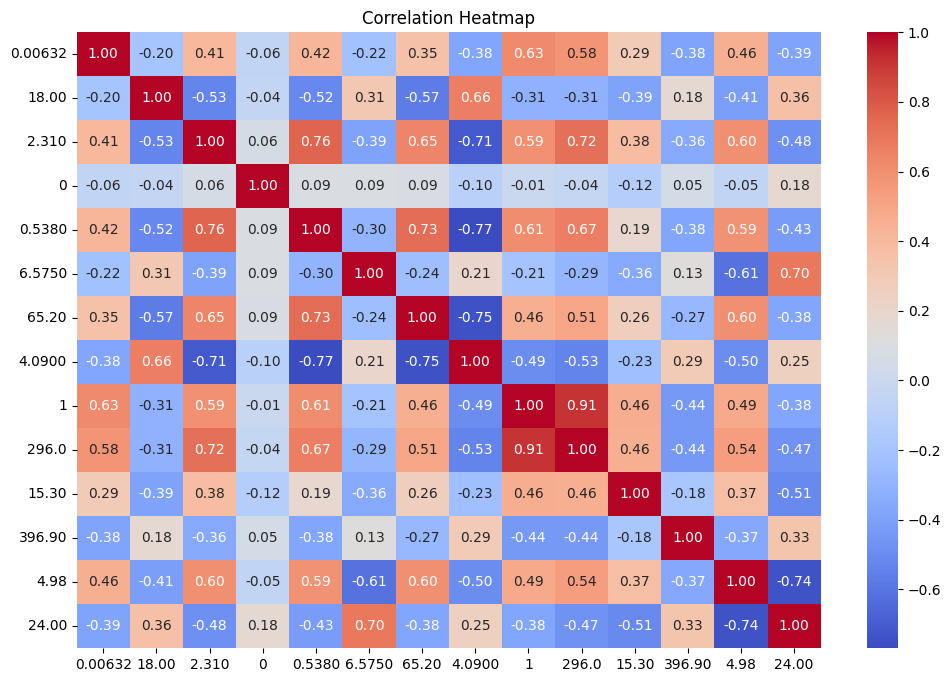

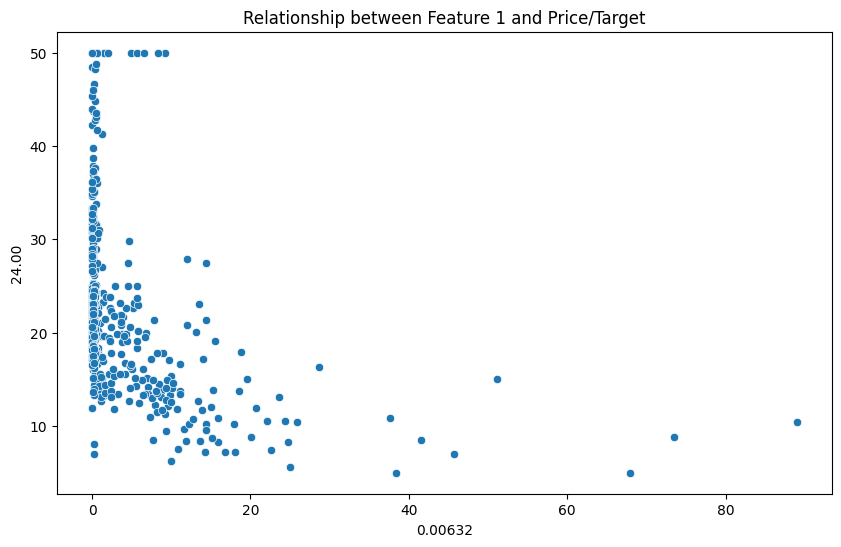

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned.iloc[:, 0], kde=True, color='blue')
plt.title('Distribution of Feature 1')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_cleaned.iloc[:, 0], y=df_cleaned.iloc[:, -1])
plt.title('Relationship between Feature 1 and Price/Target')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df_cleaned.iloc[:, :-1]
y = df_cleaned.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (Accuracy Score): {r2:.2f}")

Mean Squared Error (MSE): 19.38
R-squared (Accuracy Score): 0.65


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/Codveda_Intership/2) Stock Prices Data Set.csv'
stock_df = pd.read_csv(path)

print("Columns in this file:", stock_df.columns.tolist())

stock_df['date'] = pd.to_datetime(stock_df['date'])

stock_df.drop_duplicates(subset=['date', 'symbol'], inplace=True)

stock_df.set_index(['date', 'symbol'], inplace=True)

print("\n--- Stock Data Preview ---")
print(stock_df.head())

Columns in this file: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

--- Stock Data Preview ---
                       open      high       low     close    volume
date       symbol                                                  
2014-01-02 AAL      25.0700   25.8200   25.0600   25.3600   8998943
           AAPL     79.3828   79.5756   78.8601   79.0185  58791957
           AAP     110.3600  111.8800  109.2900  109.7400    542711
           ABBV     52.1200   52.3300   51.5200   51.9800   4569061
           ABC      70.1100   70.2300   69.4800   69.8900   1148391


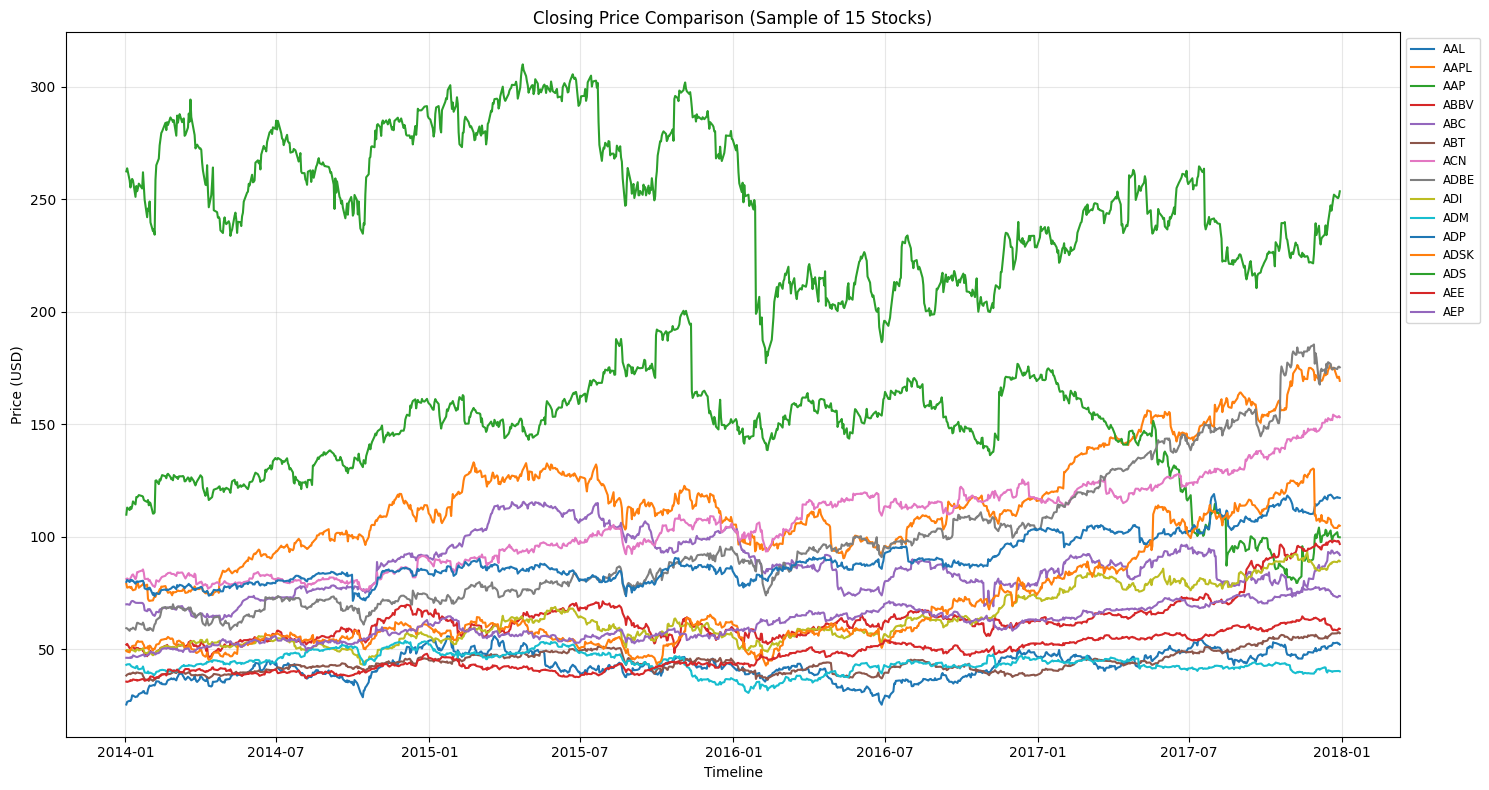

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/Codveda_Intership/2) Stock Prices Data Set.csv'
df_all = pd.read_csv(path)
df_all['date'] = pd.to_datetime(df_all['date'])
plt.figure(figsize=(15, 8))

top_symbols = df_all['symbol'].unique()[:15]

for symbol in top_symbols:
    company = df_all[df_all['symbol'] == symbol]
    plt.plot(company['date'], company['close'], label=symbol, linewidth=1.5)

plt.title('Closing Price Comparison (Sample of 15 Stocks)')
plt.xlabel('Timeline')
plt.ylabel('Price (USD)')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1, fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

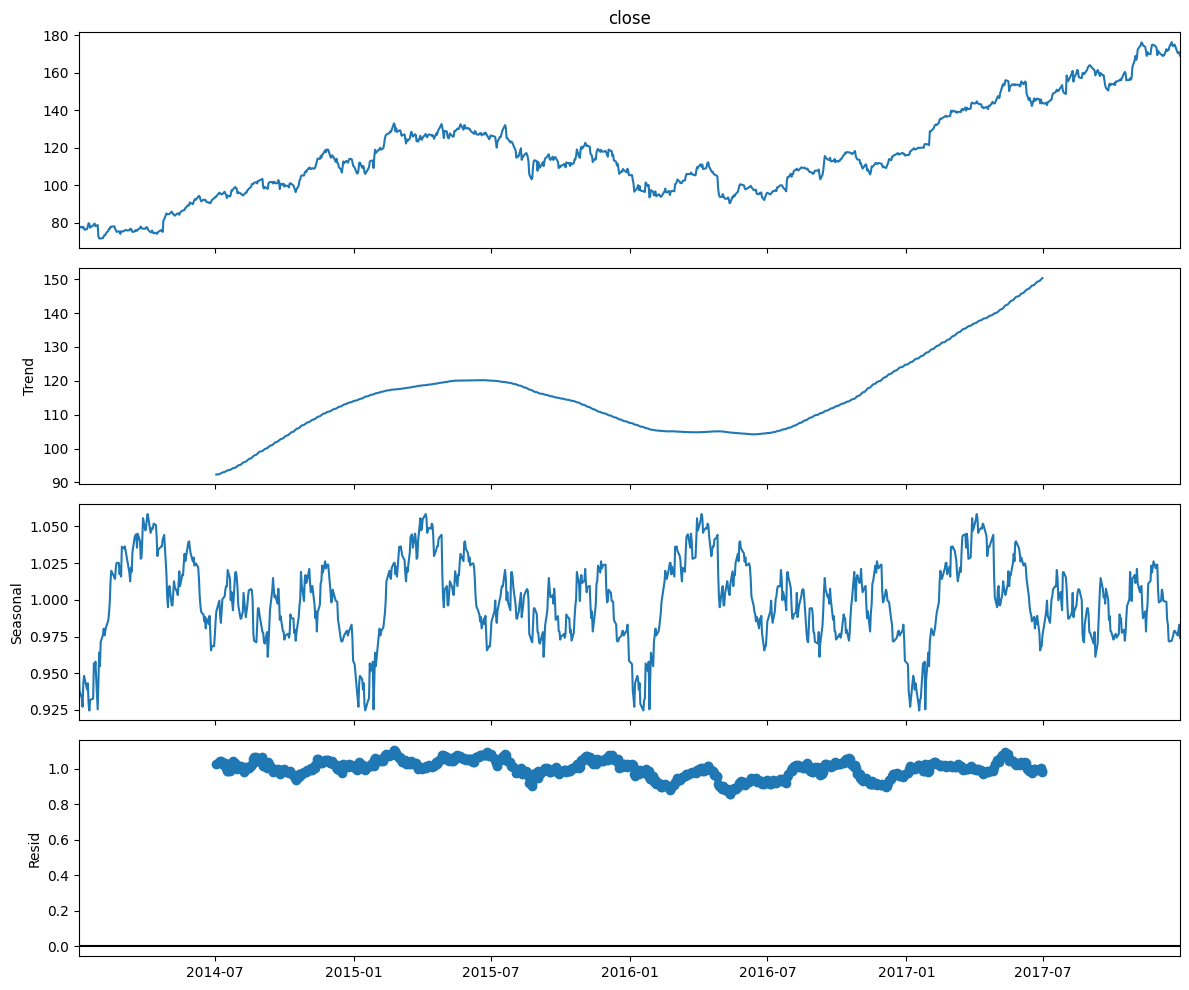

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

result = seasonal_decompose(single_stock['close'], model='multiplicative', period=252)

plt.rcParams['figure.figsize'] = (12, 10)
result.plot()
plt.show()

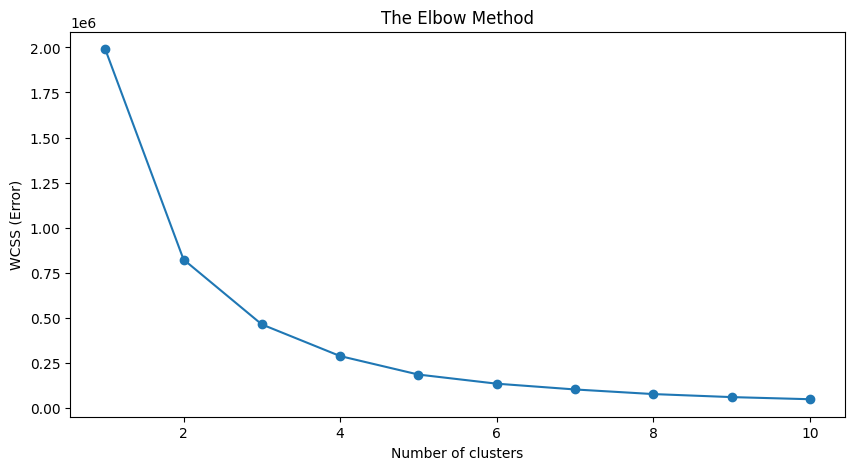

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

features = stock_df[['open', 'high', 'low', 'close']]

features_cleaned = features.dropna()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_cleaned)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Error)')
plt.show()

In [ ]:
from textblob import TextBlob
import pandas as pd
data = {
    'Review': [
        "This house is absolutely beautiful and in a great location!",
        "The stock price is falling rapidly, I am very worried.",
        "The rooms are too small and the kitchen is outdated.",
        "Excellent investment opportunity with high potential.",
        "The neighborhood is noisy and I hate the traffic here."
    ]
}

nlp_df = pd.DataFrame(data)

def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

nlp_df['Sentiment'] = nlp_df['Review'].apply(get_sentiment)
print("--- NLP Sentiment Analysis Results ---")
print(nlp_df)

--- NLP Sentiment Analysis Results ---
                                              Review Sentiment
0  This house is absolutely beautiful and in a gr...  Positive
1  The stock price is falling rapidly, I am very ...  Positive
2  The rooms are too small and the kitchen is out...  Negative
3  Excellent investment opportunity with high pot...  Positive
4  The neighborhood is noisy and I hate the traff...  Negative


In [2]:
import pandas as pd

# Re-define df_cleaned
house_data_path = '/content/drive/MyDrive/Codveda_Intership/4) house Prediction Data Set.csv'
try:
    df_fixed = pd.read_csv(house_data_path, sep=r'\s+') # Use sep=r'\s+' instead of delim_whitespace=True
except:
    df_fixed = pd.read_csv(house_data_path, sep=r'\s+') # Use sep=r'\s+'
df_cleaned = df_fixed.drop_duplicates()

# Re-define stock_df
stock_data_path = '/content/drive/MyDrive/Codveda_Intership/2) Stock Prices Data Set.csv'
stock_df = pd.read_csv(stock_data_path)
stock_df['date'] = pd.to_datetime(stock_df['date'])
stock_df.drop_duplicates(subset=['date', 'symbol'], inplace=True)
stock_df.set_index(['date', 'symbol'], inplace=True)

# 1. Export the Cleaned House Data
# This includes the 'is_expensive' category we created for Level 3
df_cleaned.to_csv('Cleaned_House_Data_Final.csv', index=False)

# 2. Export the Stock Data
# We use the original stock_df so all symbols are available for Power BI slicers
stock_df.reset_index().to_csv('Cleaned_Stock_Data_Final.csv', index=False)

print("Export Complete! Check the folder icon on the left to download.")

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_15690/3929196840.py:8: SyntaxWarning: invalid escape sequence '\s'
  df_fixed = pd.read_csv(house_data_path, sep='\s+')
/tmp/ipykernel_15690/3929196840.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_fixed = pd.read_csv(house_data_path, delim_whitespace=True)


Export Complete! Check the folder icon on the left to download.
